In [1]:
import os
os.chdir('../..')

In [ ]:
import json
import kmedoids 
import chemiscope
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import MDS, TSNE
from tqdm import tqdm
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core import Structure, Composition
from ase import Atoms
from collections import Counter

from src.datasets import MaterialsProject
from src.non_euclidean import Grassmann, Riemann, PersistentHomology, Wasserstein
from src.helper_functions import get_distances

In [35]:
mp = MaterialsProject()
mp.load()

mp.df = mp.df.with_columns(
    pl.col("formula_pretty")
    .map_elements(lambda x: Composition(x).weight, return_dtype=pl.Float64)
    .alias("weight")
)

2026-03-09 14:39:44.323 | INFO     | src.datasets:load:650 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


In [46]:
mp.df

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,acsf_embedding,soap_embedding,weight
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],f64
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[2…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",71.8444
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[3…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",223.1994
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[3…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",134.7094
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[2…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",79.5454
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[3…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]",122.4194
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,-1.309259,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[3…","""Monoclinic""","""C2/m""",2.976894,3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532,9,"[4.619654, 0.736364, … 0.0]","[0.100292, 0.26796, … 0.0]",250.776605
"""mp-23880""","""FeH4(ClO)2""",-5.265791,-1.305381,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[4…","""Monoclinic""","""C2/m""",2.287095,5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118,9,"[5.545048, 0.773538, … 0.0]","[0.100956, 0.268515, … 0.0]",162.78156
"""mp-23853""","""CoH4(ClO)2""",-5.045306,-1.233407,"""{""@module"": ""pymatgen.core.structure"", ""@class"": ""Structure"", ""charge"": 0, ""lattice"": {""matrix"": [[3…","""Monoclinic""","""C2/m""",2.424991,3.603494,5.686069,5.686069,97.465063,96.908777,96.908772,113.58114,9,"[5.775085, 0.776909, … 0.0]","[0.101054, 0.268578, … 0.0]",165.869755


In [36]:
R_CUTOFF = 15.0
adaptor = AseAtomsAdaptor()

frames_unit = [] 
frames_ph = []   
for struct_json in mp.df["raw_structure"]:
    struct = Structure.from_dict(json.loads(struct_json))
    prim = struct.get_primitive_structure()
    frames_unit.append(adaptor.get_atoms(prim))

    center_index = 0
    neighbors = struct.get_all_neighbors(r=R_CUTOFF, sites=[struct[center_index]])[0]
    
    pos = [struct[center_index].coords]
    symbols = [struct[center_index].species_string]
    
    for neighbor in neighbors:
        pos.append(neighbor.coords)
        symbols.append(neighbor.species_string)
    
    cloud = Atoms(symbols=symbols, positions=pos)
    frames_ph.append(cloud)

dist_matrices = get_distances(frames_unit, frames_ph, dataset='Materials Project/distance_matrices', include_ph = False)

2026-03-09 14:39:49.047 | INFO     | src.helper_functions:get_distances:116 - Using PH
2026-03-09 14:39:49.048 | INFO     | src.helper_functions:get_distances:126 - Loading grassmann_qr distance matrix...
2026-03-09 14:39:49.053 | INFO     | src.helper_functions:get_distances:126 - Loading grassmann_svd distance matrix...
2026-03-09 14:39:49.057 | INFO     | src.helper_functions:get_distances:126 - Loading euclidean_riemann distance matrix...
2026-03-09 14:39:49.062 | INFO     | src.helper_functions:get_distances:126 - Loading affine_riemann distance matrix...
2026-03-09 14:39:49.067 | INFO     | src.helper_functions:get_distances:126 - Loading wasserstein distance matrix...
2026-03-09 14:39:49.072 | WARNING  | src.helper_functions:get_distances:130 - Skipping PH task
2026-03-09 14:39:49.073 | WARNING  | src.helper_functions:get_distances:130 - Skipping PH task
2026-03-09 14:39:49.073 | SUCCESS  | src.helper_functions:get_distances:136 - ✓ All distance matrices are ready!


# Determining number of clusters

In [37]:
def cluster_number(dist_matrices, max_k=75):
    for name, dist_matrix in dist_matrices.items():
        print(f"Evaluating {name}...")
        
        inertias = []
        silhouettes = []
        ch_scores = []
        
        K_range = range(2, max_k)
        
        mds = MDS(n_components=5, metric="precomputed", random_state=42, n_init=2, init='classical_mds')
        X_embedded = mds.fit_transform(dist_matrix)
        
        for k in tqdm(K_range, desc=f"Testing k for {name}", leave=False):
            # 2. Fit K-Medoids with precomputed distances
            model = kmedoids.KMedoids(n_clusters=k, metric='precomputed', random_state=42)
            labels = model.fit_predict(dist_matrix)
            
            # 3. Calculate Metrics
            inertias.append(model.inertia_)
            silhouettes.append(silhouette_score(dist_matrix, labels, metric="precomputed"))
            ch_scores.append(calinski_harabasz_score(X_embedded, labels))
            
        # 4. Plotting the results
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Clustering Evaluation: {name}', fontsize=16, fontweight='bold')
        
        # Plot Inertia (Look for the "Elbow")
        axes[0].plot(K_range, inertias, marker='o', color='blue', linewidth=2)
        axes[0].set_title('Inertia (Elbow Method)')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Plot Silhouette Score (Look for the Peak)
        axes[1].plot(K_range, silhouettes, marker='s', color='green', linewidth=2)
        axes[1].set_title('Silhouette Score')
        axes[1].set_xlabel('Number of Clusters (k)')
        axes[1].set_ylabel('Score')
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        # Plot CH Score (Look for the Peak)
        axes[2].plot(K_range, ch_scores, marker='^', color='red', linewidth=2)
        axes[2].set_title('Calinski-Harabasz Score')
        axes[2].set_xlabel('Number of Clusters (k)')
        axes[2].set_ylabel('CH Score')
        axes[2].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()

Evaluating grassmann_qr...


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


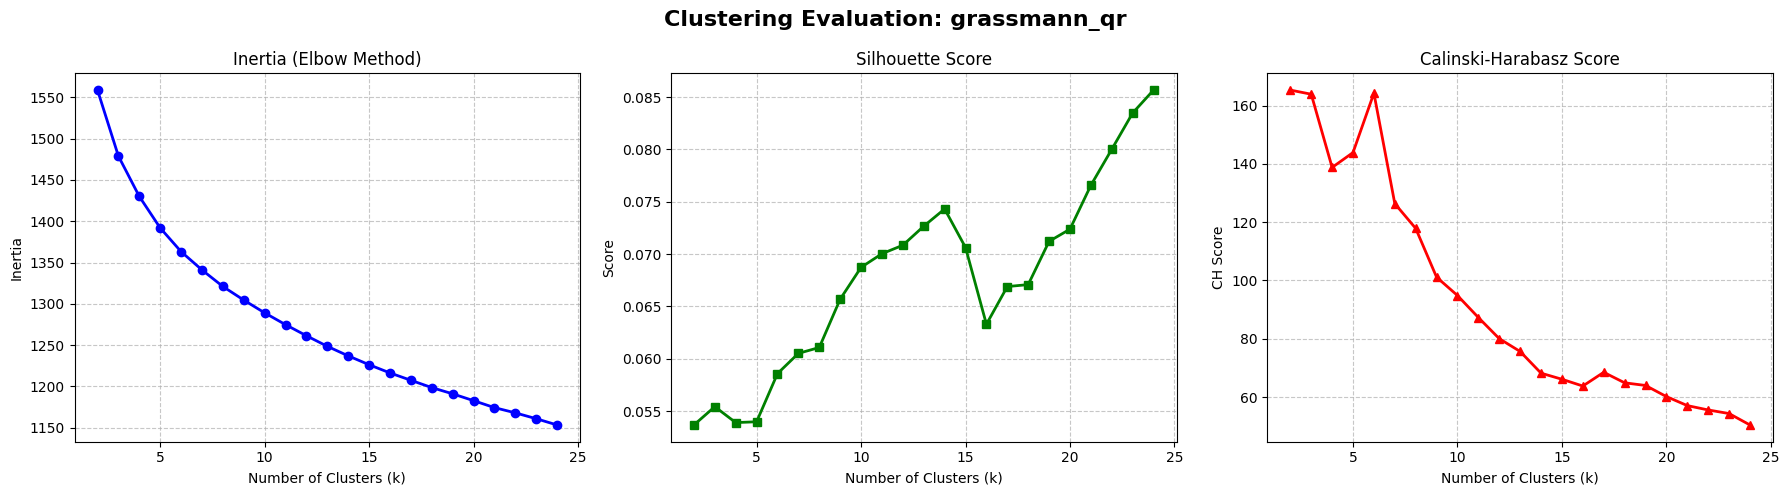

Evaluating grassmann_svd...


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


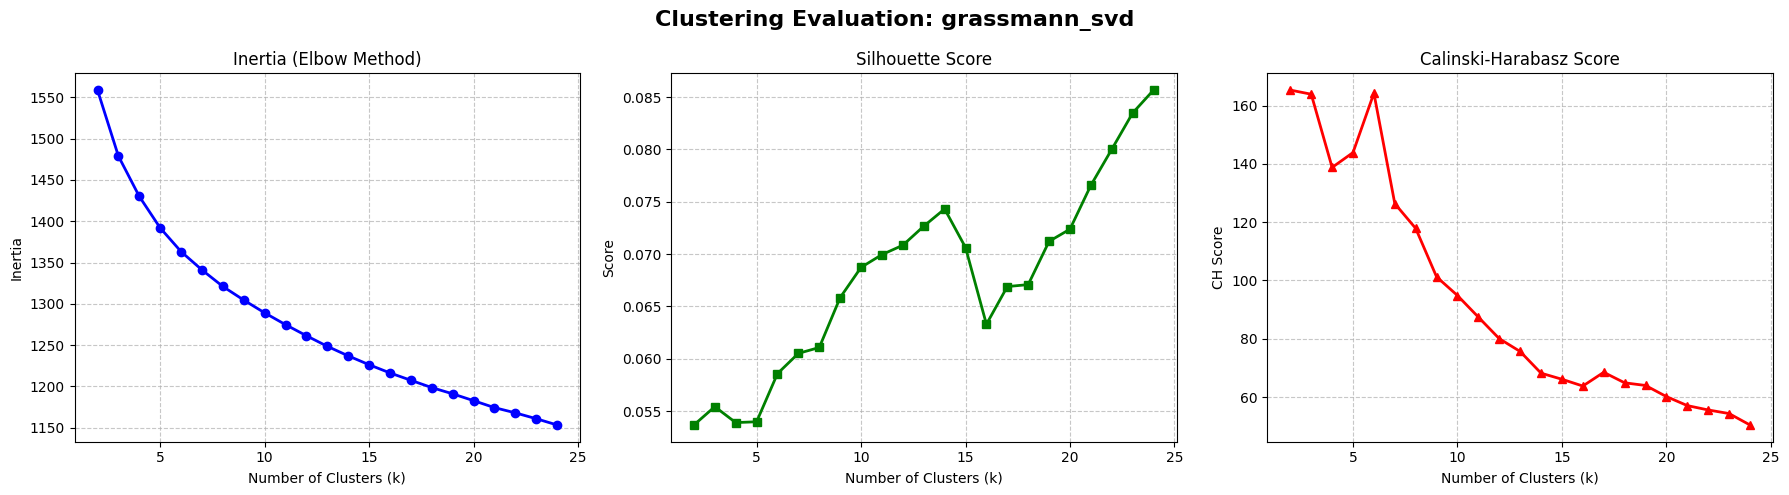

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


Evaluating euclidean_riemann...


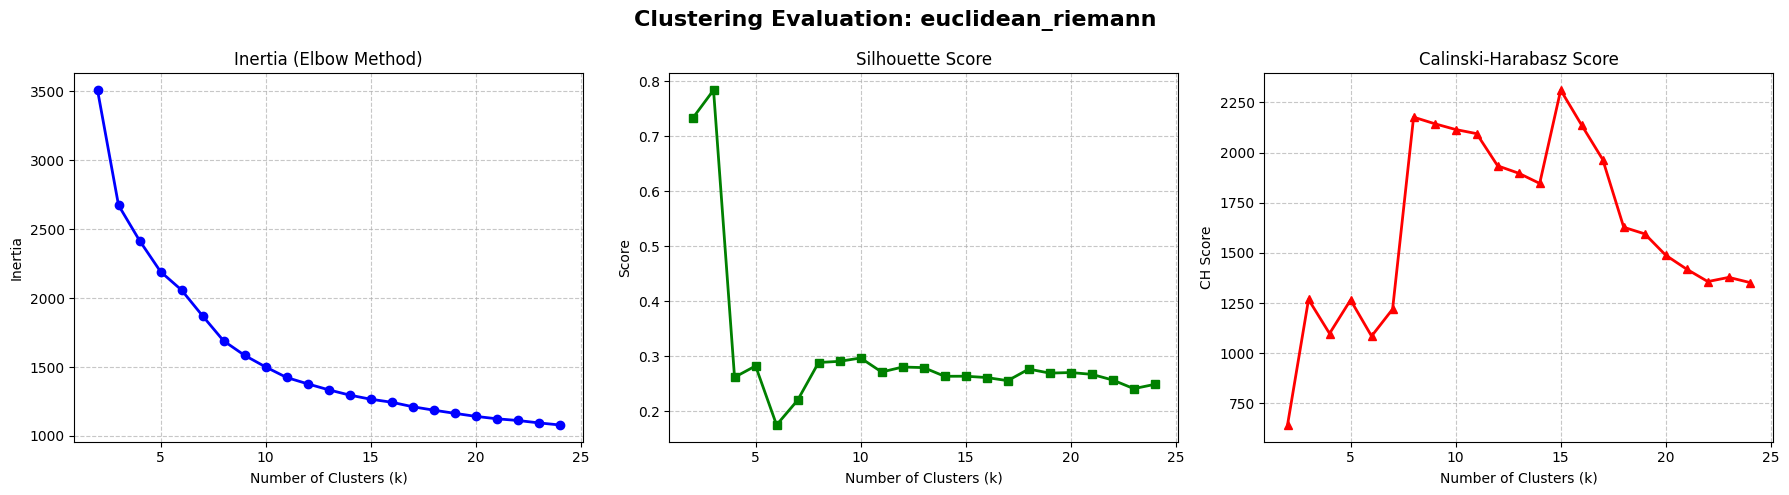

Evaluating affine_riemann...


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


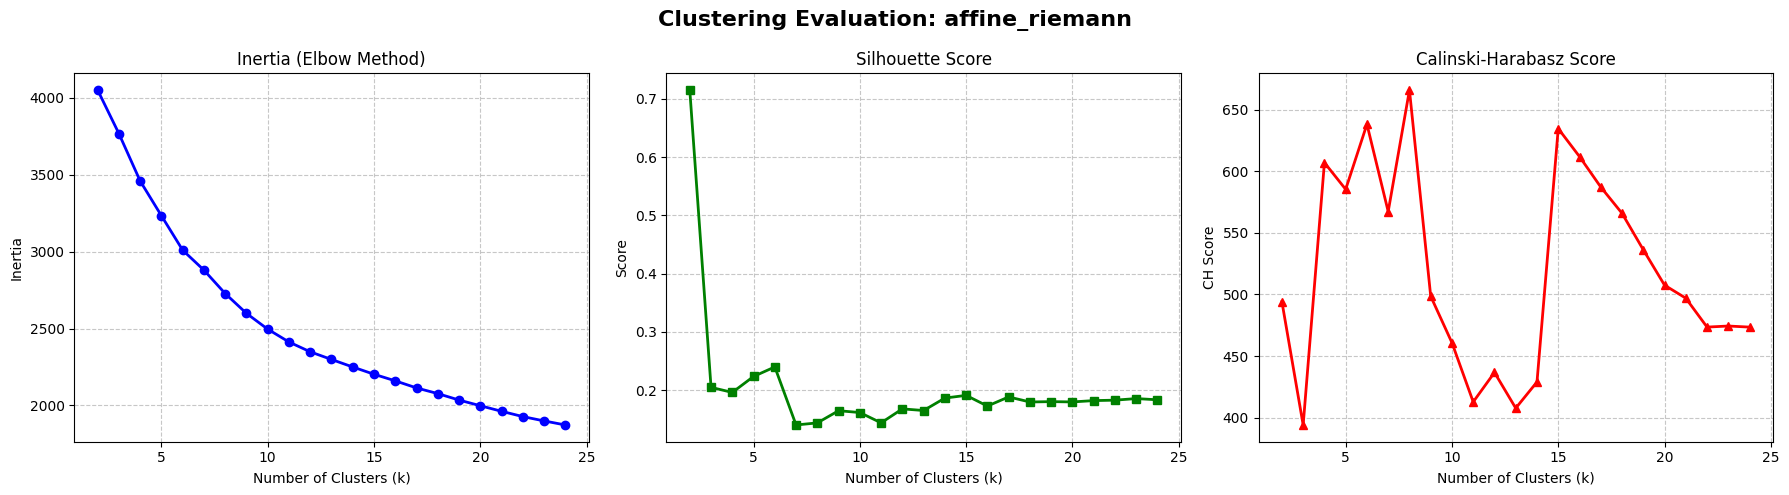

Evaluating wasserstein...


/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


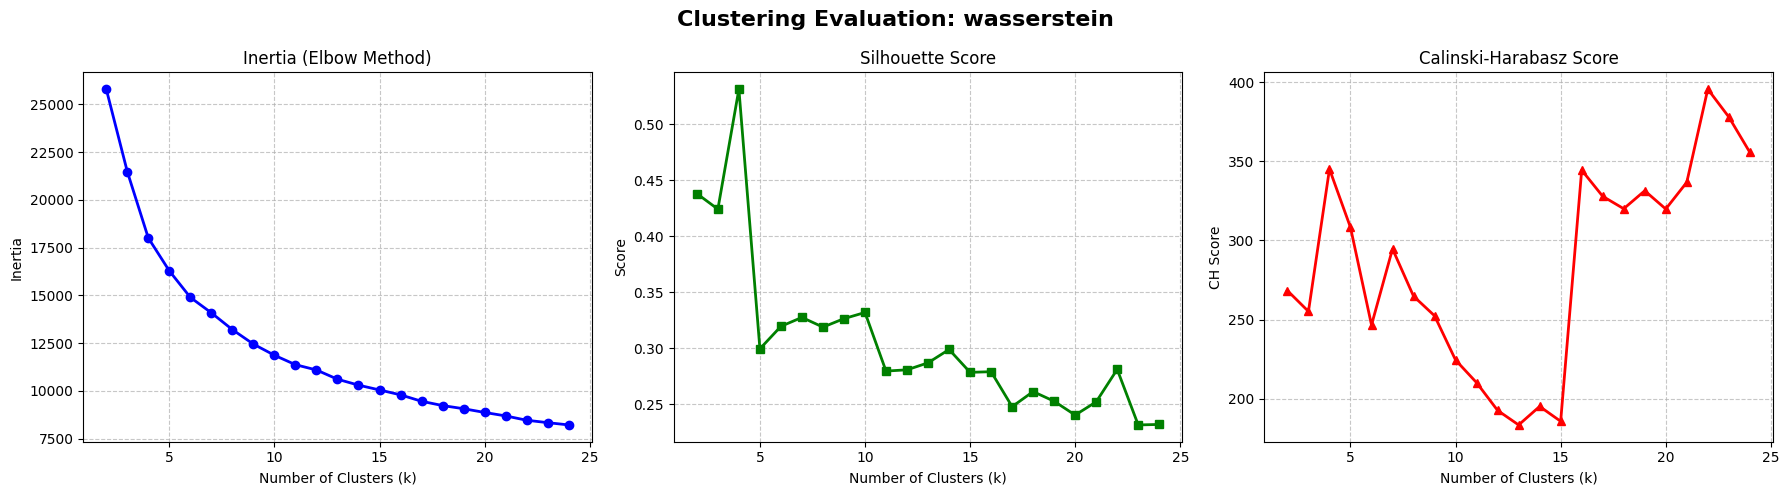

In [38]:
cluster_number(dist_matrices, max_k=25)

# best number of clusters
- grassmann: 14 - ideally around 650...
- riemann euclidean: 3
- riemann affine: 2 or 6
- wasserstein: 4

In [51]:
def plot_materials_clustering(mp_df: pl.DataFrame, dist_matrix: np.ndarray, metric_name="wasserstein", num_clusters=4):
    """
    Clusters materials using a precomputed distance matrix and generates a Chemiscope visualization.
    """
    print(f"Using precomputed '{metric_name}' distance matrix (Shape: {dist_matrix.shape})")

    model = kmedoids.KMedoids(n_clusters=num_clusters, metric='precomputed', random_state=42)
    clusters = model.fit_predict(dist_matrix)

    counts = Counter(clusters)
    print("\nCluster Distribution:")
    for i in range(num_clusters):
        print(f" - Cluster {i}: {counts[i]} materials")

    # 2. Dimensionality Reduction (t-SNE on distance matrix)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, metric="precomputed", init="random")
    X_tsne = tsne.fit_transform(dist_matrix)

    # 3. Add results and formatted strings to the Polars DataFrame
    df = mp_df.with_columns(
        pl.Series("cluster", clusters),
        pl.format("a: {}, b: {}, c: {}", 
                  pl.col("a").round(3), 
                  pl.col("b").round(3), 
                  pl.col("c").round(3)).alias("lattice_str")
    )

    df = df.with_columns(
        pl.Series("cluster", clusters),
        pl.format("alpha: {}, beta: {}, gamma: {}", 
                  pl.col("alpha").round(3), 
                  pl.col("beta").round(3), 
                  pl.col("gamma").round(3)).alias("angles_str")
    )

    # 4. Generate the Summary Table (using Polars)
    summary_table = (
        df.group_by("cluster")
        .agg([
            pl.len().alias("total_materials"),
            pl.col("formula_pretty").n_unique().alias("unique_formulas"),
            # Use .drop_nulls().first() to avoid errors if a cluster has mixed types
            pl.col("crystal_system").drop_nulls().mode().first().alias("dominant_crystal_system"),
            pl.col("space_group").drop_nulls().mode().first().alias("dominant_space_group"),
            pl.col("energy_per_atom").mean().round(3).alias("mean_energy_per_atom"),
            pl.col("density").mean().round(3).alias("mean_density")
        ])
        .sort("cluster")
    )

    pl.Config.set_fmt_str_lengths(100)
    print("\nCluster Composition Summary:")
    display(summary_table)

    # 5. Prepare ASE Frames for Chemiscope
    frames = []
    for s_str in df["raw_structure"]:
        pmg = Structure.from_dict(json.loads(s_str))
        frames.append(AseAtomsAdaptor.get_atoms(pmg))

    # 6. Define Properties Dictionary mapping Polars columns
    properties = {
        "Cluster": clusters.astype(int),
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Material ID": df["material_id"].to_list(),
        "Formula": df["formula_pretty"].to_list(),
        "Crystal System": df["crystal_system"].to_list(),
        "Space Group": df["space_group"].to_list(),
        "Energy per Atom": df["energy_per_atom"].to_numpy(),
        "Formation Energy": df["formation_energy_per_atom"].to_numpy(),
        "Density": df["density"].to_numpy(),
        "Volume": df["volume"].to_numpy(),
        "Lattice (a,b,c)": df["lattice_str"].to_list(),
        "Angles (alpha, beta, gamma)" : df["angles_str"].to_list(),
    }
    
    # Safely add weight if you calculated it previously
    if "weight" in df.columns:
        properties["Weight"] = df["weight"].to_numpy()

    # 7. Chemiscope Settings and Export
    os.makedirs("report/materials_project/figures", exist_ok=True)
    output_path = f"report/materials_project/figures/chemiscope_{metric_name}_k{num_clusters}.json.gz"

    settings = {
        "map": {
            "x": {"property": "t-SNE 1"},
            "y": {"property": "t-SNE 2"},
            "color": {"property": "Cluster"},
            "size": {"factor": 35}
        },
        "structure": [{"unitcell": True, "keepOrientation": True}]
    }

    chemiscope.write_input(
        path=output_path,
        structures=frames,
        properties=properties,
        settings=settings,
        metadata={
            "name": f"MP Clustering ({metric_name})",
            "description": f"KMedoids (k={num_clusters}) using {metric_name} distance matrix."
        }
    )

    print(f"\nChemiscope file successfully saved to: {output_path}")

    return summary_table, output_path

# Grassmann

In [52]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['grassmann_qr'], 
                                                       num_clusters=25, 
                                                       metric_name='grassmann'
                                                       )
chemiscope.show_input(output_path)

Using precomputed 'grassmann' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 43 materials
 - Cluster 1: 44 materials
 - Cluster 2: 66 materials
 - Cluster 3: 33 materials
 - Cluster 4: 31 materials
 - Cluster 5: 38 materials
 - Cluster 6: 36 materials
 - Cluster 7: 51 materials
 - Cluster 8: 28 materials
 - Cluster 9: 48 materials
 - Cluster 10: 56 materials
 - Cluster 11: 38 materials
 - Cluster 12: 27 materials
 - Cluster 13: 45 materials
 - Cluster 14: 44 materials
 - Cluster 15: 47 materials
 - Cluster 16: 18 materials
 - Cluster 17: 67 materials
 - Cluster 18: 24 materials
 - Cluster 19: 30 materials
 - Cluster 20: 27 materials
 - Cluster 21: 35 materials
 - Cluster 22: 35 materials
 - Cluster 23: 47 materials
 - Cluster 24: 42 materials

Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,43,43,"""Monoclinic""","""P2_1/c""",-5.508,3.9
1,44,44,"""Orthorhombic""","""Pbca""",-6.182,4.656
2,66,66,"""Trigonal""","""P-3m1""",-8.4,7.149
3,33,33,"""Trigonal""","""R-3m""",-6.426,5.36
4,31,31,"""Tetragonal""","""I4/mmm""",-5.565,4.355
…,…,…,…,…,…,…
20,27,27,"""Tetragonal""","""I4/mmm""",-6.203,5.703
21,35,34,"""Trigonal""","""R-3m""",-8.071,6.201
22,35,35,"""Orthorhombic""","""Pnma""",-5.293,4.451



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_grassmann_k25.json.gz


<ChemiscopeWidget(meta={'name': 'MP Clustering (grassmann)', 'description': 'KMedoids (...}, settings={'map': …

# Riemann

In [41]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['euclidean_riemann'], 
                                                       num_clusters=3, 
                                                       metric_name='euclidean_riemann'
                                                       )
chemiscope.show_input(output_path)

Using precomputed 'euclidean_riemann' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 895 materials
 - Cluster 1: 48 materials
 - Cluster 2: 57 materials

Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,895,887,"""Orthorhombic""","""I4/mmm""",-6.41,5.21
1,48,48,"""Trigonal""","""R-3m""",-8.15,6.259
2,57,57,"""Trigonal""","""R-3m""",-6.859,5.788



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_euclidean_riemann_k3.json.gz


<ChemiscopeWidget(meta={'name': 'MP Clustering (euclidean_riemann)', 'description': 'KM...}, settings={'map': …

In [44]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['affine_riemann'], 
                                                       num_clusters=2, 
                                                       metric_name='riemann_affine'
                                                       )
chemiscope.show_input(output_path)

Using precomputed 'riemann_affine' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 954 materials
 - Cluster 1: 46 materials

Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,954,946,"""Orthorhombic""","""I4/mmm""",-6.44,5.245
1,46,46,"""Trigonal""","""R-3m""",-8.178,6.309



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_riemann_affine_k2.json.gz


<ChemiscopeWidget(meta={'name': 'MP Clustering (riemann_affine)', 'description': 'KMedo...}, settings={'map': …

# Wasserstein

In [45]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['wasserstein'], 
                                                       num_clusters=4, 
                                                       metric_name='wasserstein'
                                                       )
chemiscope.show_input(output_path)

Using precomputed 'wasserstein' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 208 materials
 - Cluster 1: 670 materials
 - Cluster 2: 63 materials
 - Cluster 3: 59 materials

Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,208,208,"""Orthorhombic""","""Pnma""",-5.603,4.212
1,670,663,"""Tetragonal""","""I4/mmm""",-6.739,5.579
2,63,63,"""Trigonal""","""R-3m""",-7.313,5.657
3,59,58,"""Monoclinic""","""R-3m""",-6.417,5.478



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_wasserstein_k4.json.gz


<ChemiscopeWidget(meta={'name': 'MP Clustering (wasserstein)', 'description': 'KMedoids...}, settings={'map': …